# FAPE, Student Performance Fairness Intervention: ThresholdOptimizer

Phase 4, fairness intervention (Stage 3 of the framework) in the education domain. The script applies Fairlearn's ThresholdOptimizer post-processing to the Student Performance baseline models and tests the demographic parity and equalized odds constraints by sex. Math (395 records) and Portuguese (649 records) are evaluated separately. The label is a final grade (G3) above the subject median; the loader excludes the G1 and G2 grades (target leakage) and stores sex as category codes ("0" = F, "1" = M). With 79 test records in Math, about 40 per sex, one student moves a group's rate by 2.5 points. Figure 6 shows the female-to-male selection-rate ratio for the gradient boosting baseline only. ThresholdOptimizer.predict is seeded (random_state=42), so runs are repeatable.

Code: `src/stage2_student_threshold.py`. This notebook runs that script, so its printed output and figures are the ones the paper uses.

In [1]:
import os, sys, warnings, logging

# The data loaders read paths relative to the repository root (data/raw/...), so run from there.
# The check stops a second run of this cell from moving up another directory.
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
if os.path.abspath('src') not in sys.path:
    sys.path.insert(0, os.path.abspath('src'))
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)
from IPython.display import Image, display

# matplotlib 3.8.4 (pinned) imports backend2gui from IPython when a script makes its first figure
# inside a kernel, and IPython 9 removed it. An empty mapping is what IPython 8 gave for Agg.
import IPython.core.pylabtools
if not hasattr(IPython.core.pylabtools, 'backend2gui'):
    IPython.core.pylabtools.backend2gui = {}

In [2]:
from stage2_student_threshold import run_stage2

run_stage2()

FAPE Phase 4, Student Performance Fairness Intervention: ThresholdOptimizer

--- Loading Student Performance Data ---


  Downloaded: student-mat (395 rows), student-por (649 rows)
  OK: student_math: 395 rows | 30 features | positive rate: 0.410 | median grade: 11.0
  OK: student_portuguese: 649 rows | 30 features | positive rate: 0.425 | median grade: 12.0
  Subjects: ['math', 'portuguese']

--- Subject: math (n=395) ---
  Baseline LogisticRegression     ACC=0.646 DPD=0.212 EOD=0.204
  Baseline RandomForest           ACC=0.633 DPD=0.235 EOD=0.263


  Baseline GradientBoosting       ACC=0.658 DPD=0.237 EOD=0.314
  DP LogisticRegression         ACC=0.620(-0.025) DPD=0.010(-0.201)


  DP RandomForest               ACC=0.557(-0.076) DPD=0.363(+0.128)
  DP GradientBoosting           ACC=0.582(-0.076) DPD=0.215(-0.021)
  EO LogisticRegression         ACC=0.646(+0.000) EOD=0.188(-0.015)


  EO RandomForest               ACC=0.633(+0.000) EOD=0.180(-0.082)
  EO GradientBoosting           ACC=0.658(+0.000) EOD=0.114(-0.200)

--- Subject: portuguese (n=649) ---
  Baseline LogisticRegression     ACC=0.731 DPD=0.314 EOD=0.326


...

  DP RandomForest               ACC=0.615(-0.146) DPD=0.360(+0.177)
  DP GradientBoosting           ACC=0.754(+0.015) DPD=0.010(-0.291)
  EO LogisticRegression         ACC=0.754(+0.023) EOD=0.121(-0.205)


  EO RandomForest               ACC=0.754(-0.008) EOD=0.204(-0.005)
  EO GradientBoosting           ACC=0.754(+0.015) EOD=0.292(-0.064)

--- Fairness Summary by Subject ---
  math: Base DPD=0.237 DP DPD=0.215 Base EOD=0.314 EO EOD=0.114
  portuguese: Base DPD=0.301 DP DPD=0.010 Base EOD=0.356 EO EOD=0.292

--- Key Findings ---
  Test records: math 79, portuguese 130
  math: above-median rate F=0.375 M=0.436 | GB baseline F/M DIR=0.487
  math: DPD worse after the DP constraint: RandomForest
  portuguese: above-median rate F=0.461 M=0.370 | GB baseline F/M DIR=2.084
  portuguese: DPD worse after the DP constraint: RandomForest

--- Generating Figures ---


Fig 1 saved, student_accuracy_comparison.png
Fig 2 saved, student_dpd_before_after.png


Fig 3 saved, student_eod_before_after.png
Fig 4 saved, student_sex_prediction_rates.png


Fig 5 saved, student_f1_comparison.png
Fig 6 saved, student_dir_by_sex.png

--- Student intervention complete ---
  6 figures saved to figures/stage2/


## 1. Accuracy by subject

Accuracy of each model at baseline and under each constraint, for Math and Portuguese.

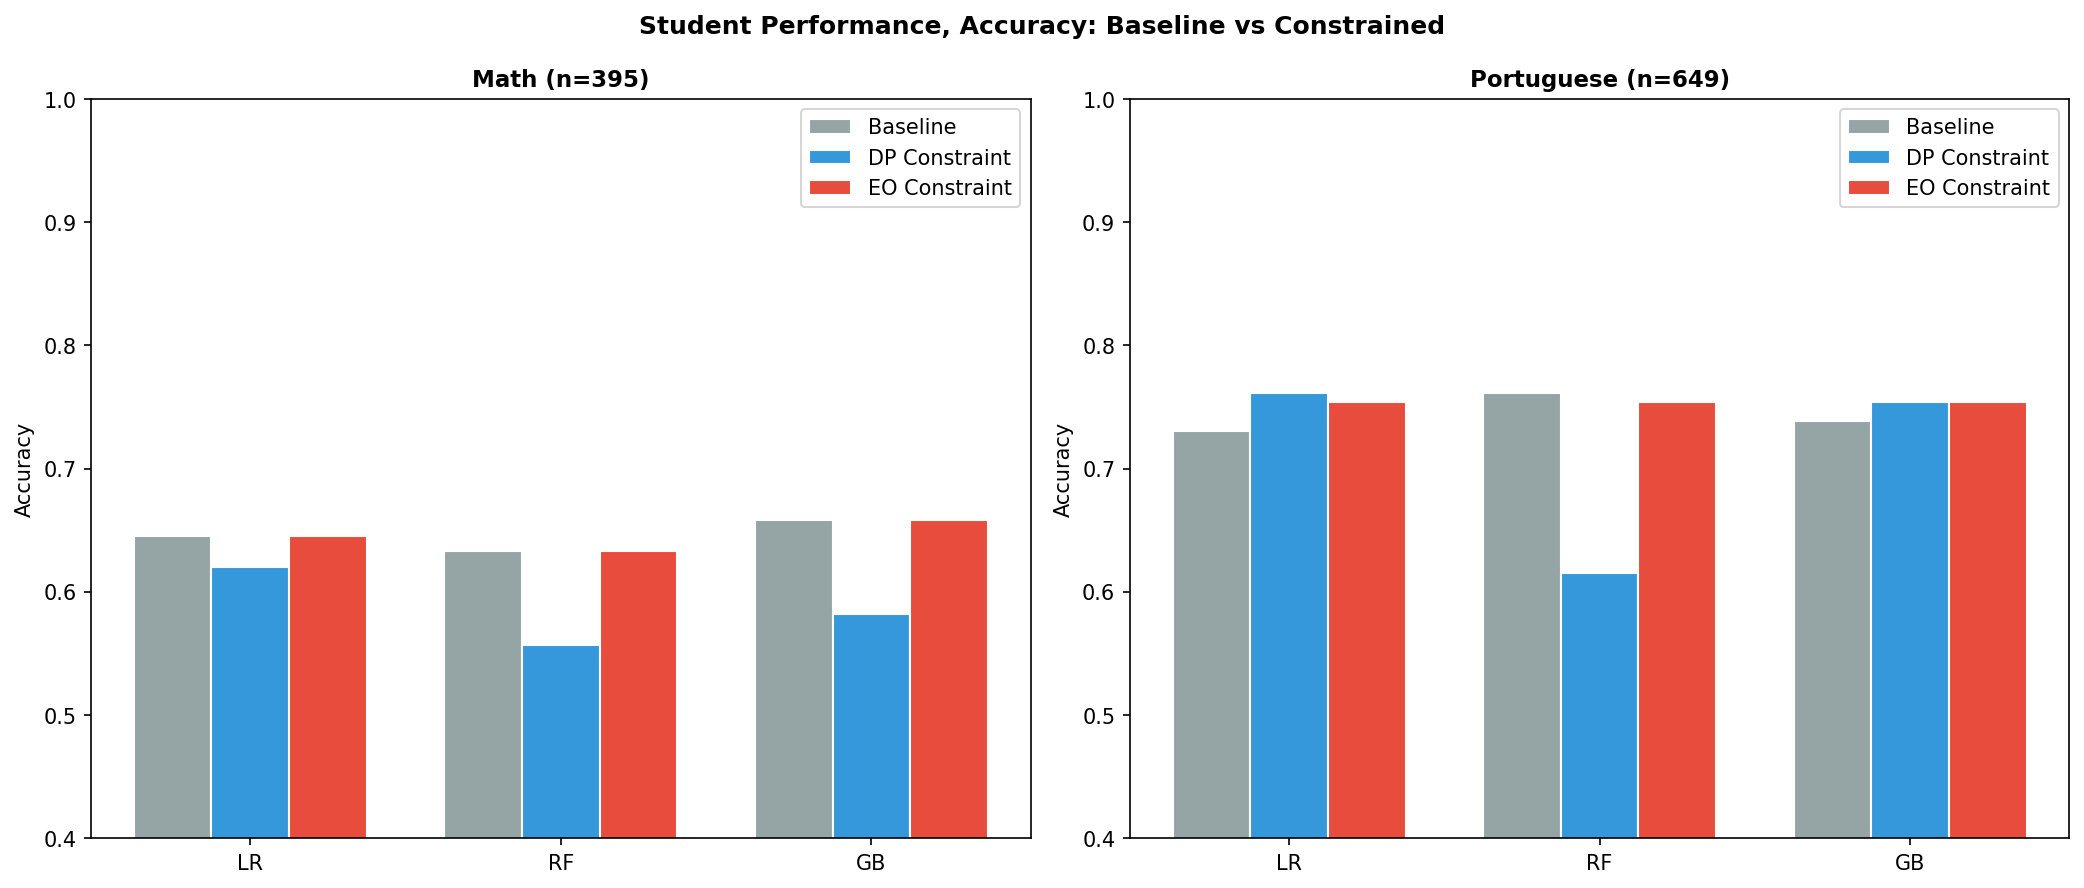

In [3]:
display(Image('figures/stage2/student_accuracy_comparison.png'))

## 2. DPD before and after the demographic parity constraint

Sex demographic parity difference for each model before and after the constraint, by subject.

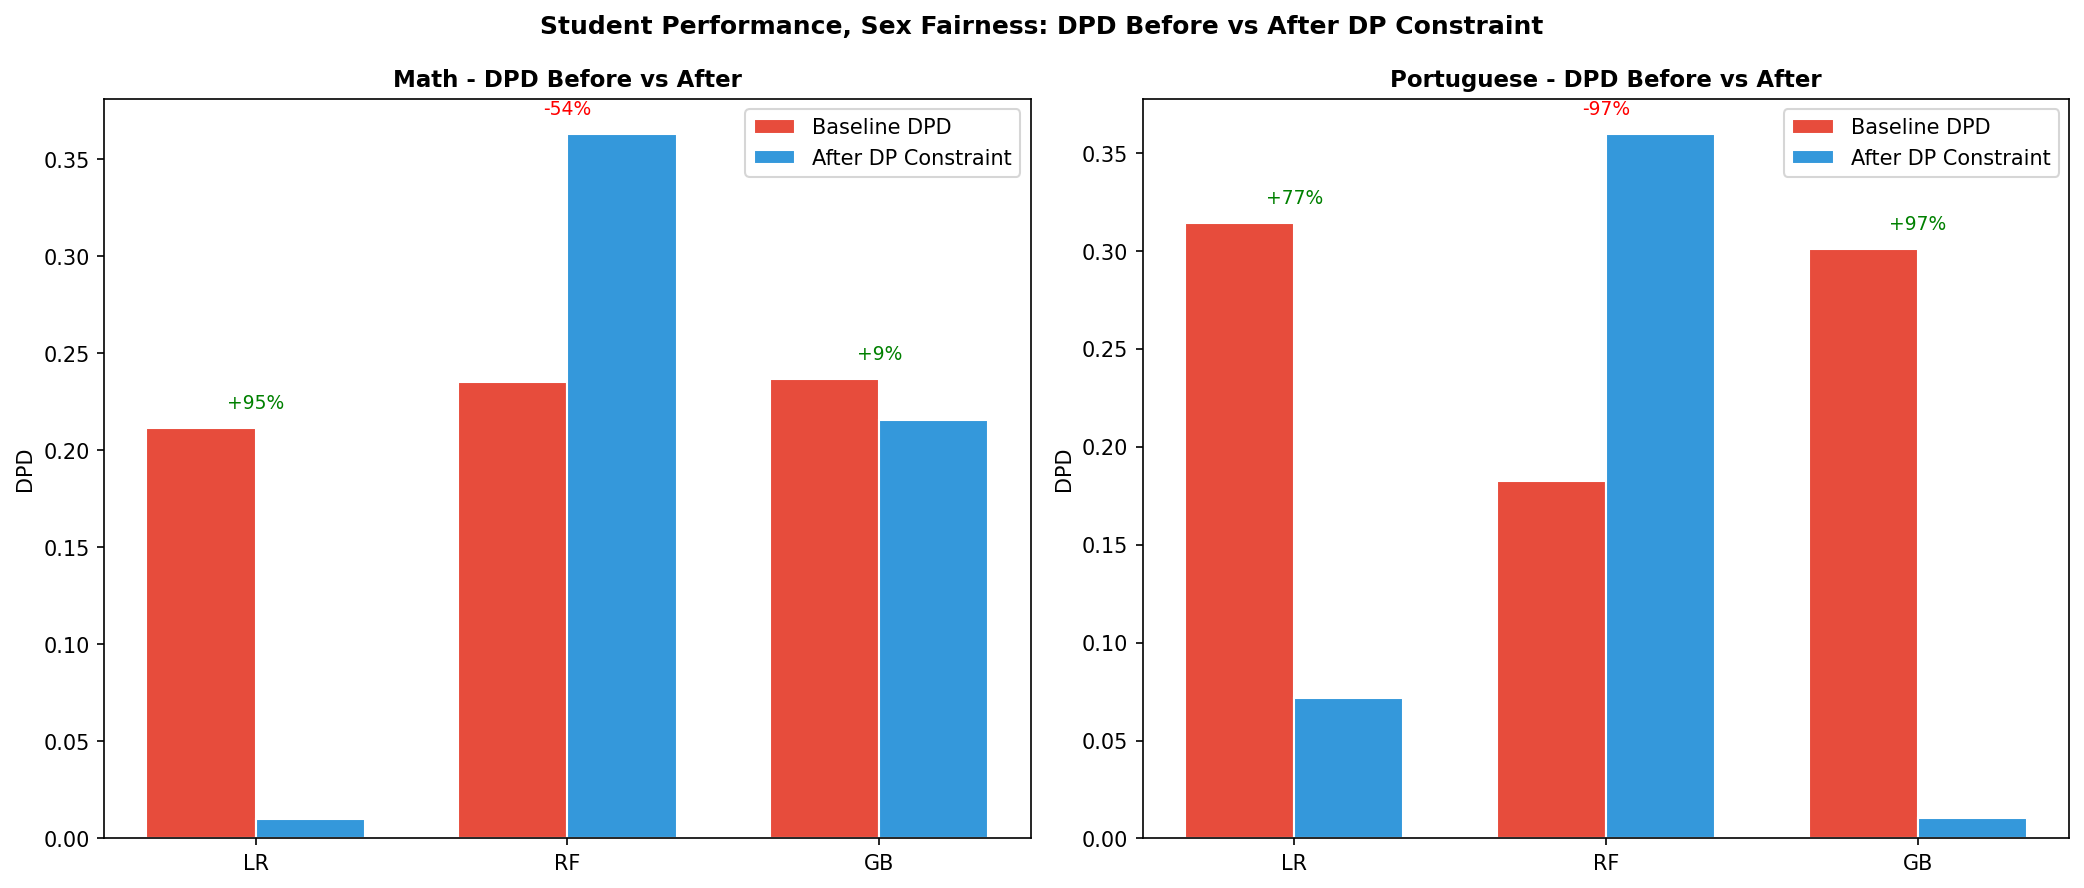

In [4]:
display(Image('figures/stage2/student_dpd_before_after.png'))

## 3. EOD before and after the equalized odds constraint

Sex equalized odds difference for each model before and after the constraint, by subject.

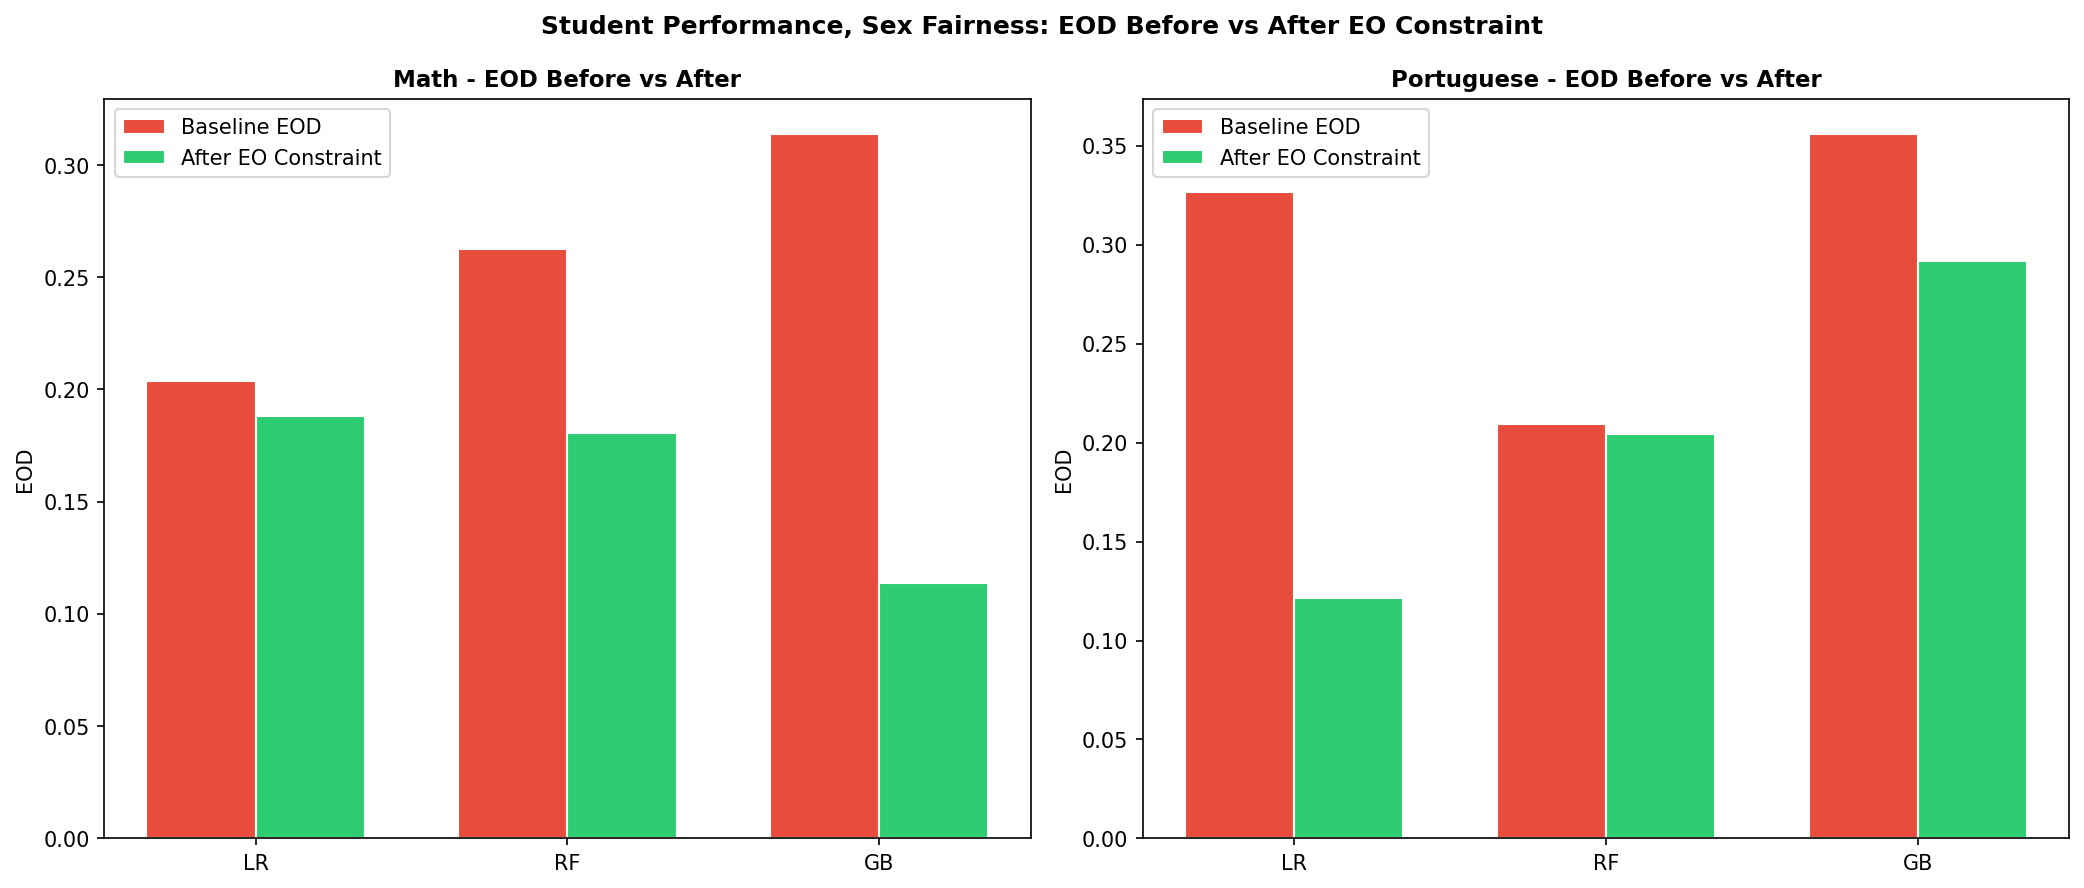

In [5]:
display(Image('figures/stage2/student_eod_before_after.png'))

## 4. True and predicted rates by sex

True positive-label rate and gradient boosting's predicted rate for female and male students, by subject.

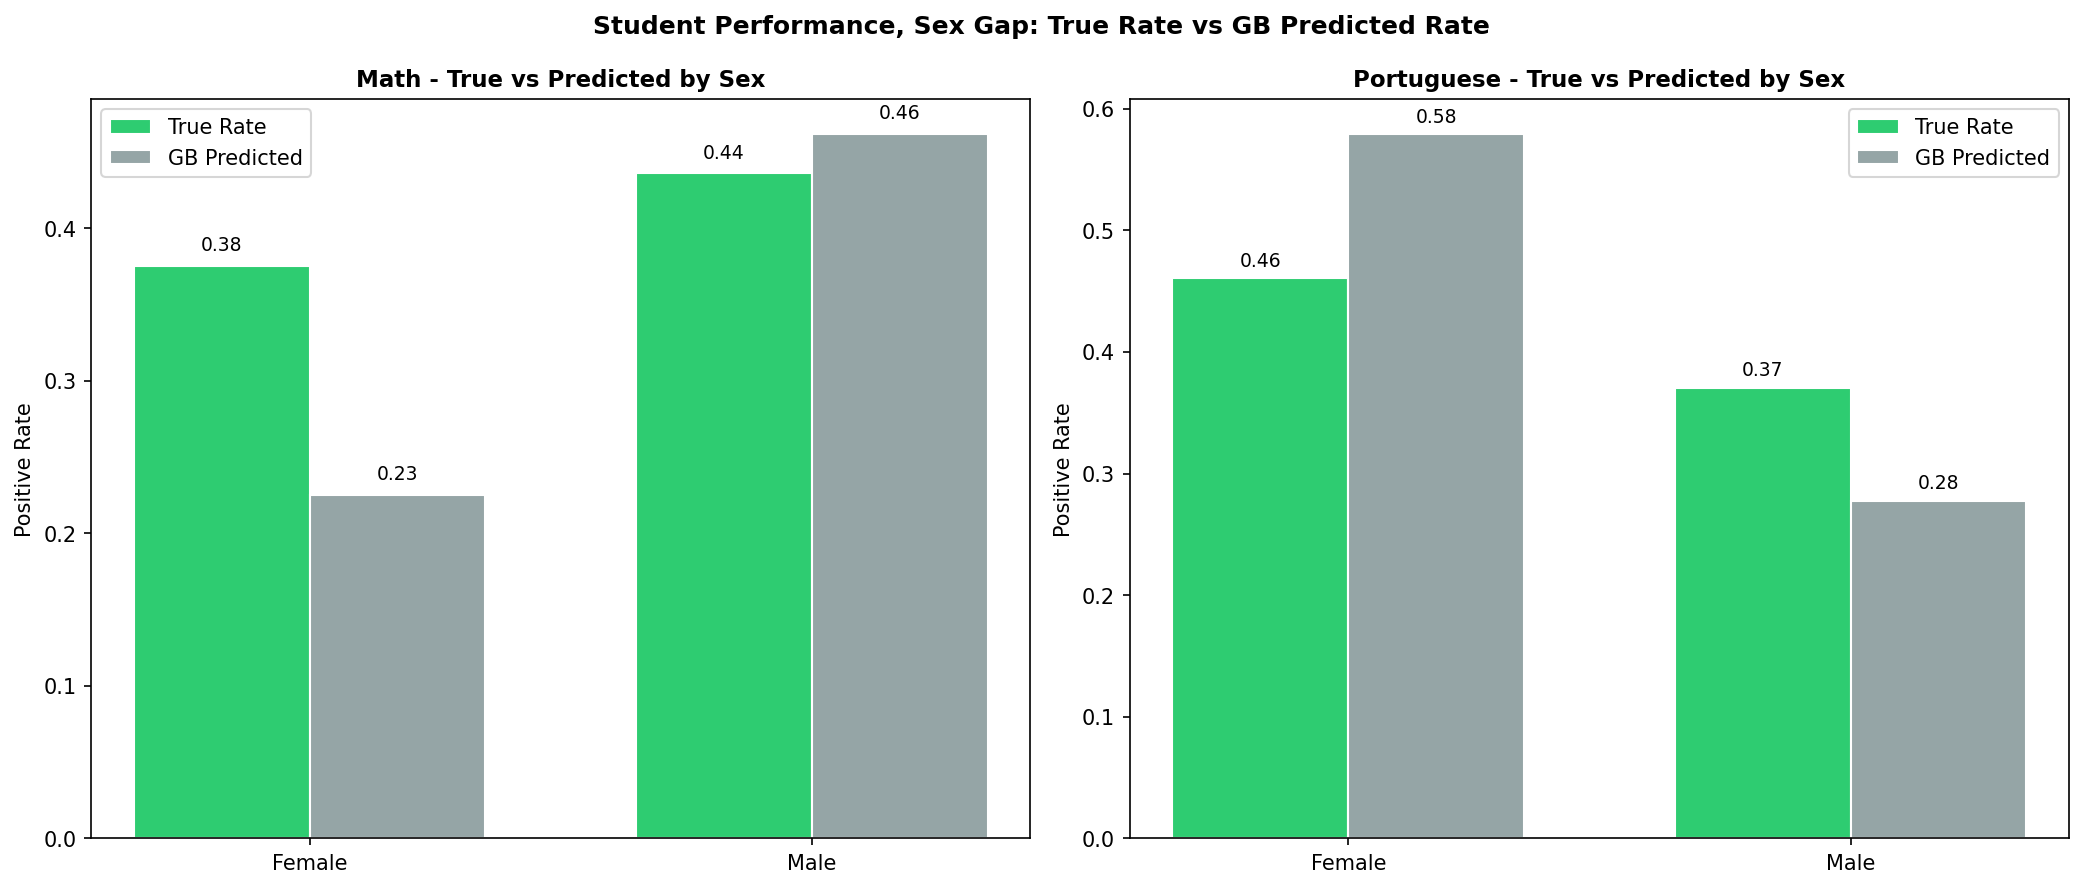

In [6]:
display(Image('figures/stage2/student_sex_prediction_rates.png'))

## 5. F1 by subject

F1 score of each model at baseline and under each constraint, by subject.

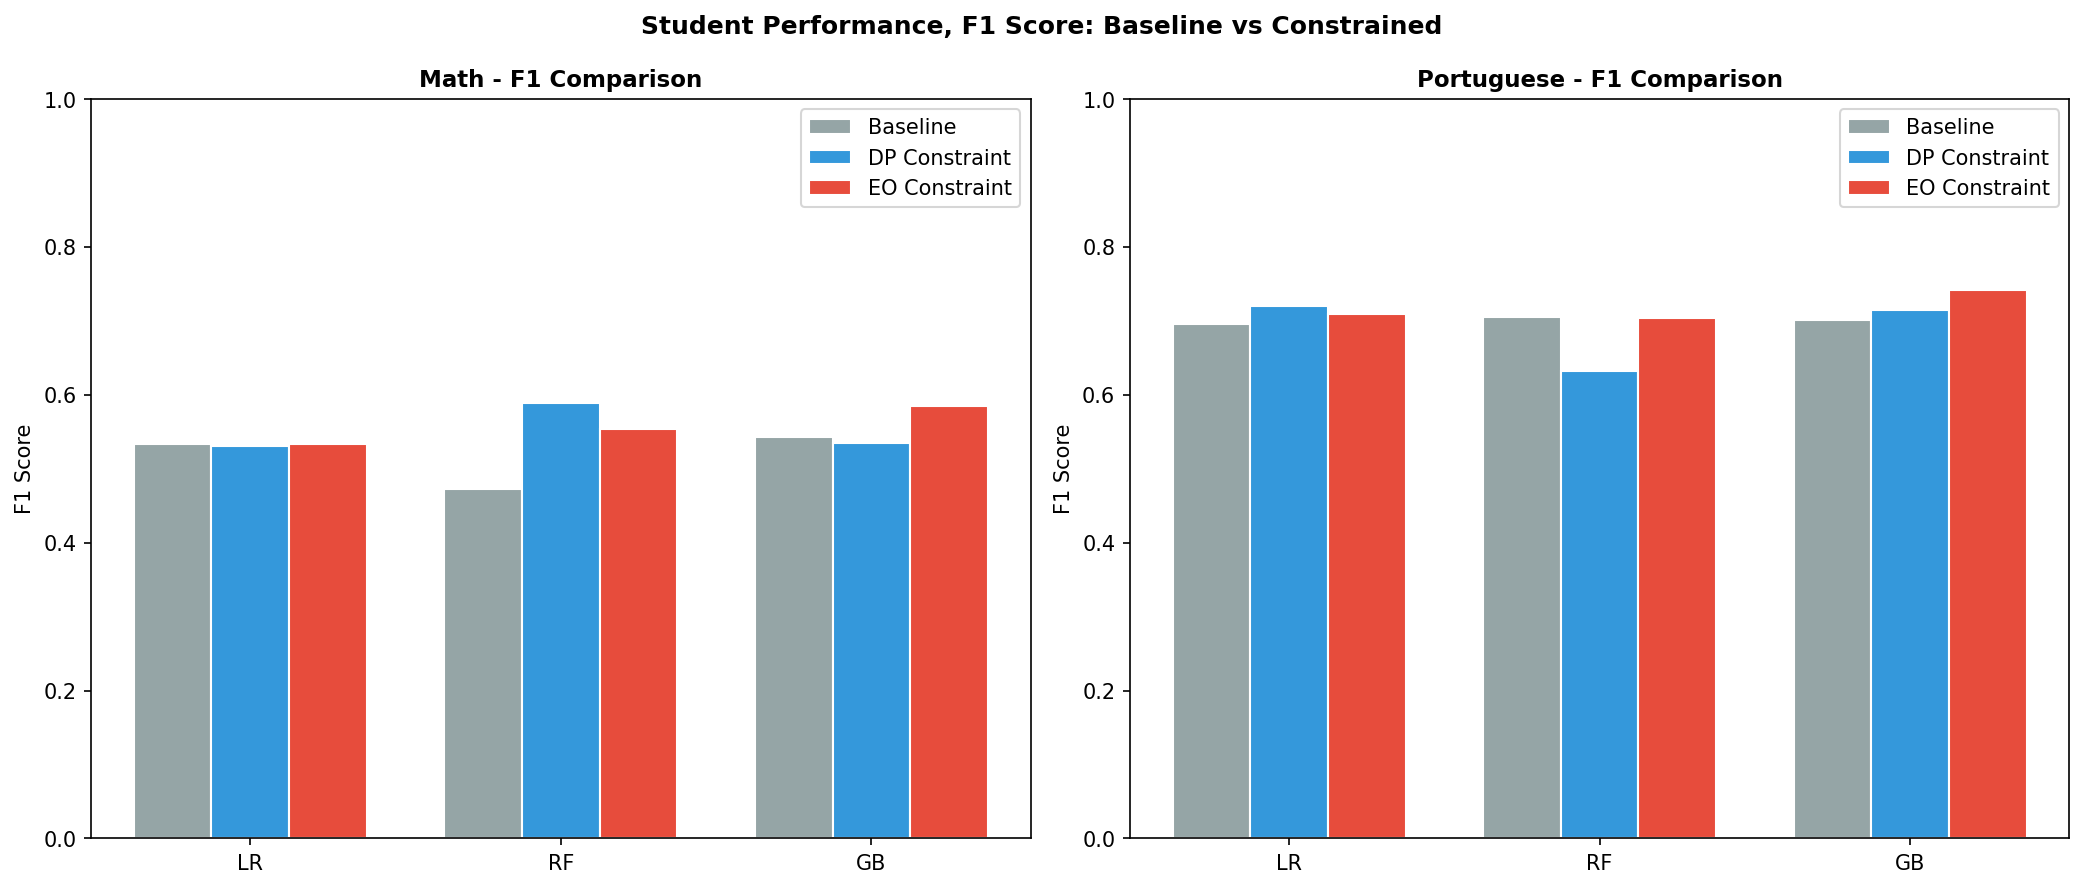

In [7]:
display(Image('figures/stage2/student_f1_comparison.png'))

## 6. Selection-rate ratio by sex

Female-to-male and male-to-female selection-rate ratios for the gradient boosting baseline, by subject.

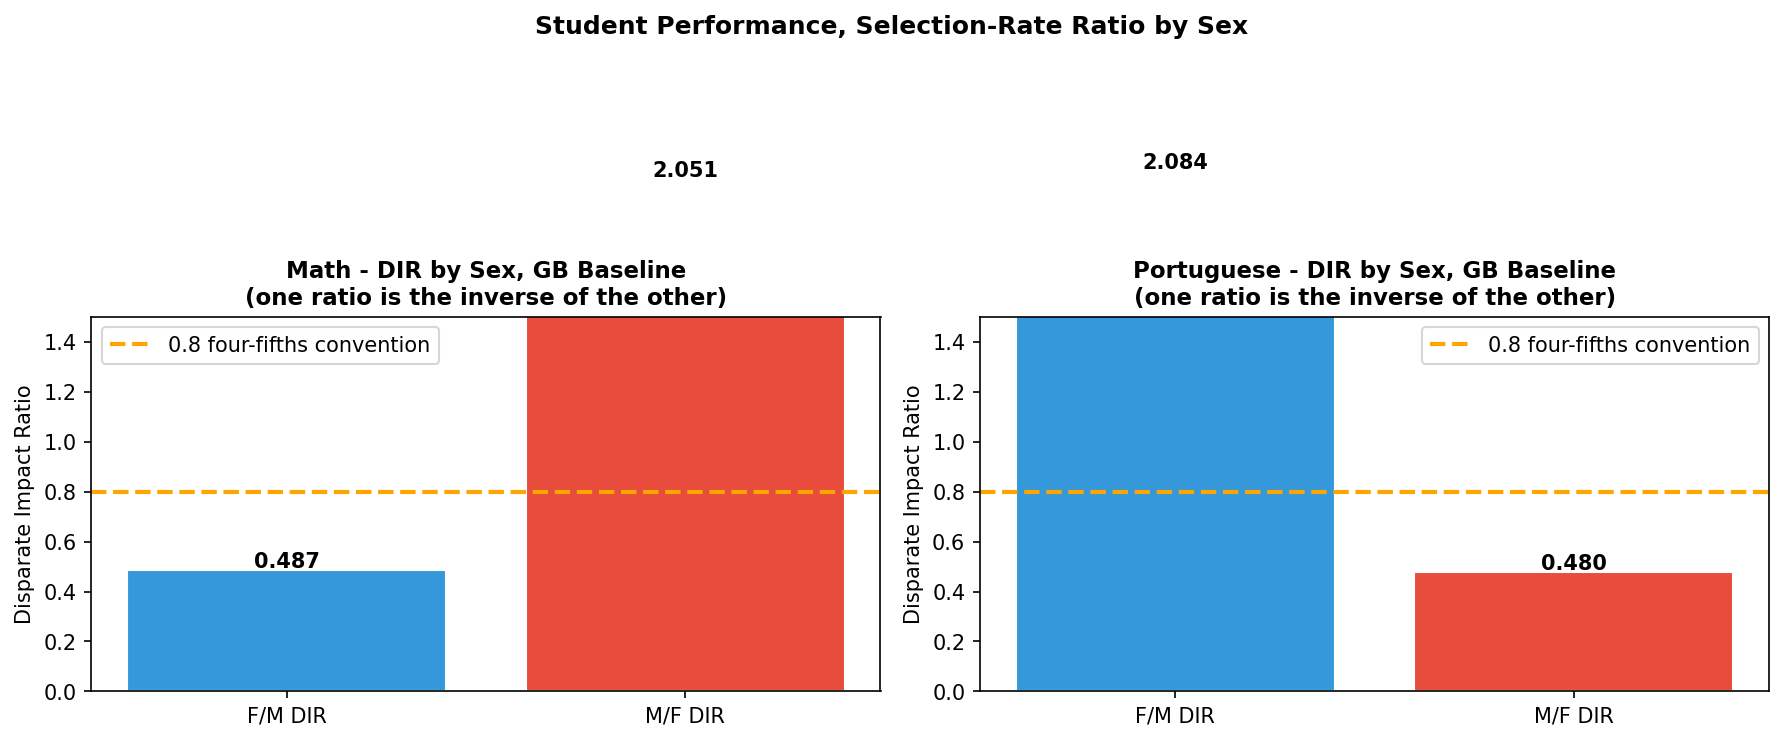

In [8]:
display(Image('figures/stage2/student_dir_by_sex.png'))

## Printed findings

The script's computed findings are in the output of the run cell above.